# Logistic Regression

Logistic regression is used for **classification**, not regression, despite the name. This notebook builds up the intuition from scratch — starting with why linear regression breaks down on classification data — before using sklearn's `LogisticRegression`.

## 0. Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

## 1. Why Linear Regression Isn't Ideal for Classification

The target here is binary: `passed` is either 0 or 1. It's tempting to just fit a `LinearRegression` line to it like any other numeric target — but this causes two problems:

1. The line can predict values **below 0 or above 1**, which makes no sense as a probability.
2. The line is **sensitive to outliers** far along the x-axis, which can drag the whole decision boundary in a bad direction — even though those points don't really change how confident we should be.

Let's see this happen directly.

In [2]:
df = pd.read_csv('exam_pass.csv')
df.head()

,hours_studied,prior_score,passed
0,4.36,65.1,1
1,0.26,65.4,0
2,5.50,45.3,1
3,4.35,30.3,1
4,4.20,59.2,1


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


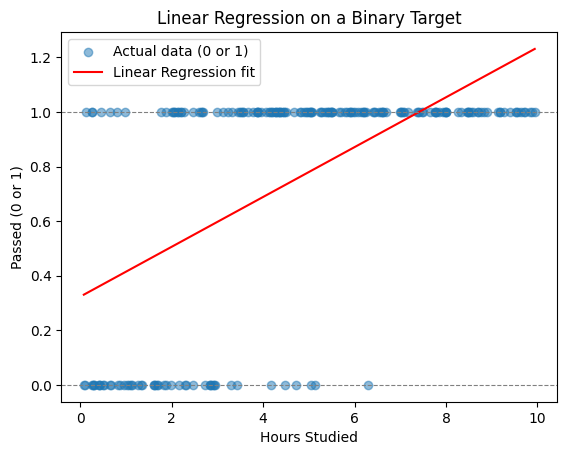

In [3]:
# Fit a plain LinearRegression on a single feature vs the 0/1 target
X_simple = df[['hours_studied']]
y_simple = df['passed']

lin_reg = LinearRegression()
lin_reg.fit(X_simple, y_simple)

x_range = np.linspace(df['hours_studied'].min(), df['hours_studied'].max(), 100).reshape(-1,1)
y_range = lin_reg.predict(x_range)

plt.scatter(df['hours_studied'], df['passed'], alpha=0.5, label='Actual data (0 or 1)')
plt.plot(x_range, y_range, color='red', label='Linear Regression fit')
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axhline(1, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('Hours Studied')
plt.ylabel('Passed (0 or 1)')
plt.legend()
plt.title('Linear Regression on a Binary Target')
plt.show()

Notice the line goes below 0 and above 1 well within the range of the data — those aren't valid probabilities. Linear regression has no built-in way to keep predictions bounded between 0 and 1. This is exactly the gap logistic regression fills.

## 2. Binary Classification

**Binary classification** means predicting one of exactly two classes — here, `passed = 1` or `passed = 0` (fail). Instead of predicting a number directly, the goal becomes: estimate the **probability** that a given input belongs to the positive class (1), then convert that probability into a final class decision.

In [4]:
df['passed'].value_counts()

passed
1    150
0     50
Name: count, dtype: int64

## 3. Sigmoid

The **sigmoid function** solves the "line goes out of bounds" problem. It takes any real number `z` and squashes it into the range (0, 1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}$$

- Large positive `z` → output close to 1
- Large negative `z` → output close to 0
- `z = 0` → output exactly 0.5

This shape is what lets logistic regression output something that behaves like a probability.

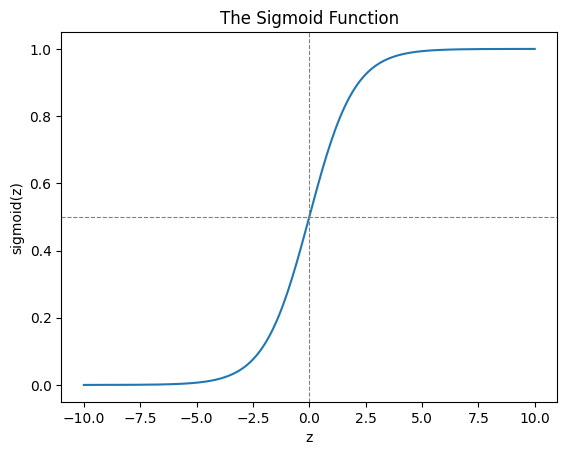

In [5]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z_values = np.linspace(-10, 10, 200)
plt.plot(z_values, sigmoid(z_values))
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.title('The Sigmoid Function')
plt.show()

## 4. Probability

Logistic regression still starts with the same linear combination as linear regression:

$$z = w_1 x_1 + w_2 x_2 + ... + b$$

But instead of using `z` directly as the prediction, it passes `z` through the sigmoid to get a **probability**:

$$P(y=1 \mid x) = \sigma(z) = \frac{1}{1 + e^{-z}}$$

So the model isn't saying "pass" or "fail" directly — it's saying "there's an 82% chance this student passes," and that probability is what gets turned into a final decision.

In [6]:
# Manual example: pick arbitrary weights/bias and compute a probability for one student
w, b = 0.7, -3.5   # made-up weight/bias, just to illustrate the formula
hours = 6

z = w * hours + b
p = sigmoid(z)
print(f"z = {z:.2f}")
print(f"P(pass) = {p:.4f}")

z = 0.70
P(pass) = 0.6682


## 5. Decision Boundary

The probability alone isn't a class label — it needs a cutoff. The default **decision boundary** is `p = 0.5`:

- `p > 0.5` → predict class 1 (pass)
- `p ≤ 0.5` → predict class 0 (fail)

Since `sigmoid(0) = 0.5`, this boundary corresponds to exactly `z = 0`. Everything is about where `z` crosses zero.

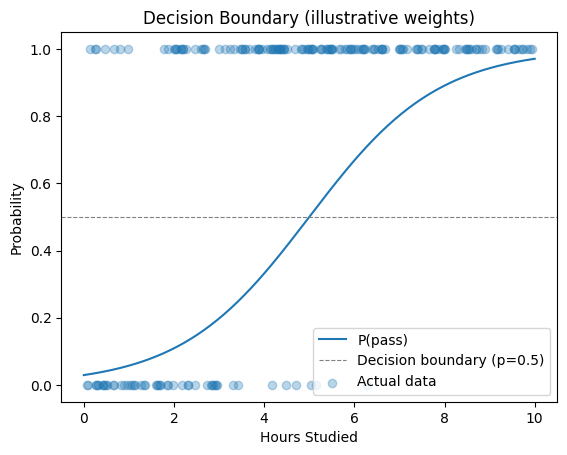

In [7]:
hours_range = np.linspace(0, 10, 200)
z_range = w * hours_range + b
p_range = sigmoid(z_range)

plt.plot(hours_range, p_range, label='P(pass)')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='Decision boundary (p=0.5)')
plt.scatter(df['hours_studied'], df['passed'], alpha=0.3, label='Actual data')
plt.xlabel('Hours Studied')
plt.ylabel('Probability')
plt.legend()
plt.title('Decision Boundary (illustrative weights)')
plt.show()

## 6. Logistic Regression Intuition — Putting It Together

Logistic regression learns the weights `w` and bias `b` (instead of us picking them by hand like above) so that the sigmoid curve fits the data as well as possible — pushing `P(pass)` close to 1 for students who passed and close to 0 for students who failed.

It does this by minimizing a loss function called **log loss** (not squared error like linear regression), which penalizes confident-but-wrong predictions heavily. The exact optimization is handled internally by sklearn — what matters here is the shape of the idea:

`features → linear combination (z) → sigmoid → probability → threshold → class`

## 7. `LogisticRegression`

Now let's let sklearn actually learn the weights, using both features this time.

In [8]:
X = df[['hours_studied', 'prior_score']]
y = df['passed']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)

clf = LogisticRegression()
clf.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [9]:
clf.coef_, clf.intercept_

(array([[1.12813681, 0.07671659]]), array([-7.27631006]))

## 8. `.predict()`

Returns the final predicted class (0 or 1) — this already applies the 0.5 threshold internally.

In [10]:
clf.predict(X_test.iloc[[0]])

array([1])

In [11]:
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9000


In [12]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 8  3]
 [ 1 28]]


## 9. `.predict_proba()`

Returns the actual probabilities behind the decision — `[P(class 0), P(class 1)]`. Useful whenever you need more than a yes/no, e.g. to rank predictions by confidence or use a custom threshold instead of 0.5.

In [13]:
clf.predict_proba(X_test.iloc[[0]])

array([[0.00698435, 0.99301565]])

In [14]:
# Compare predict() vs predict_proba() side by side for the first 5 test samples
probs = clf.predict_proba(X_test)[:5, 1]   # P(pass) for each
preds = clf.predict(X_test)[:5]

for p, pred in zip(probs, preds):
    print(f"P(pass) = {p:.4f}  ->  predicted class = {pred}")

P(pass) = 0.9930  ->  predicted class = 1
P(pass) = 0.9448  ->  predicted class = 1
P(pass) = 0.9946  ->  predicted class = 1
P(pass) = 0.9917  ->  predicted class = 1
P(pass) = 0.4121  ->  predicted class = 0


## 10. Practice on Your Dataset

Swap in a dataset of your own — replace the CSV path and column names below and re-run the same fit → predict → evaluate steps.

In [15]:
# TODO: replace with your own dataset
# my_df = pd.read_csv('your_dataset.csv')
# X = my_df[['feature1', 'feature2']]
# y = my_df['target']
#
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=2)
# clf = LogisticRegression()
# clf.fit(X_train, y_train)
# accuracy_score(y_test, clf.predict(X_test))